# Tier A — the Rouse equilibrium profile

**What this tests.** Settling, turbulent mixing and the resuspension release
height, *jointly*. This is the most diagnostic case in Tier A: it is the only one
where all three have to be right at once for the answer to come out.

**The analytic answer.** With a parabolic diffusivity and a constant settling
velocity, the steady state of the vertical advection–diffusion balance is the
Rouse (1937) distribution,

$$ \frac{C(z_b)}{C(a)} = \left[\frac{h-z_b}{z_b}\cdot\frac{a}{h-a}\right]^{P},
\qquad P = \frac{w_s}{\kappa u_*} $$

$P$ is the Rouse number: small $P$ means a well-mixed suspension, large $P$ means
material hugging the bed. Recovering $P$ from the modelled profile is the test.

**Why `reference` release, not the production `turbulent` mode.** The `turbulent`
mode draws lift-off heights *from the Rouse distribution itself*, so testing a
Rouse profile against it would be partly circular. Using a fixed release height
removes that: the profile then has to be built by settling against mixing.

Test: `tests/models/test_sppm_analytic.py::test_rouse_equilibrium_profile`

In [1]:
# Tier A - Rouse equilibrium profile
import sys, pathlib, warnings
warnings.filterwarnings("ignore")

# locate the repository root (the directory containing `opendrift/`)
_p = pathlib.Path.cwd().resolve()
while not (_p / "opendrift" / "__init__.py").exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
CLR = ["#0b6fa4", "#e07b39", "#3f9b52", "#b4434e", "#7c5aa6"]
print("repo:", REPO)

repo: /home/smullersoares/projects/software/opendrift


## Setup

A 20 m column with $u_* = 0.02$ m/s. We sweep two Rouse numbers by choosing
$w_s = P \kappa u_*$; each is a separate 24 h run.

P = 0.25  ->  w_s =  2.00 mm/s
P = 0.50  ->  w_s =  4.00 mm/s


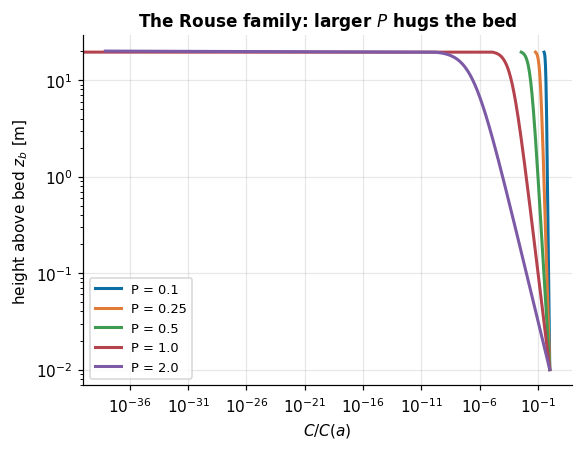

In [2]:
import datetime
from tests.models.sppm_harness import (column_dataset, column_model, seed_column,
                                       height_above_bed, rouse_profile, KAPPA)

H, U_STAR, ZA, N, HOURS = 20.0, 0.02, 0.01, 4000, 24
PS = [0.25, 0.50]

for P in PS:
    print(f"P = {P:4.2f}  ->  w_s = {P*KAPPA*U_STAR*1e3:5.2f} mm/s")

zb = np.logspace(np.log10(ZA), np.log10(H), 300)
fig, ax = plt.subplots(figsize=(5.4, 4.2))
for P, c in zip([0.1, 0.25, 0.5, 1.0, 2.0], CLR):
    ax.plot(rouse_profile(zb, P, H, ZA), zb, color=c, lw=2, label=f'P = {P}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$C/C(a)$'); ax.set_ylabel(r'height above bed $z_b$ [m]')
ax.set_title('The Rouse family: larger $P$ hugs the bed')
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()

## Run

Each run seeds a uniform cloud, sets `tau_crit` effectively to zero so material
recirculates continuously, and lets the profile find its equilibrium over 24 h.

In [3]:
results = {}
for P in PS:
    w_s = P * KAPPA * U_STAR
    ds = column_dataset(h=H, u=0.3, u_star=U_STAR, hours=HOURS + 2)
    o, reader = column_model(
        ds,
        vertical_mixing__settling_model='prescribed',
        vertical_mixing__tau_crit_mode='constant',
        vertical_mixing__resuspension_height_mode='reference',
        vertical_mixing__resuspension_reference_height=ZA,
        vertical_mixing__bbl_scheme='legacy')
    seed_column(o, reader, N, H, w_s, tau_crit=1e-9)
    o.run(time_step=300, time_step_output=3600,
          duration=datetime.timedelta(hours=HOURS), stop_on_error=True)
    results[P] = dict(zb=height_above_bed(o, H),
                      n_bed=int(np.sum(o.elements.settled == 1)))
    print(f"P={P}: {results[P]['n_bed']} of {N} elements resting on the bed at the end")

P=0.25: 267 of 4000 elements resting on the bed at the end


P=0.5: 887 of 4000 elements resting on the bed at the end


## Result

Concentration is a count per unit height in log-spaced bins. Elements *resting on
the bed* awaiting their next lift-off are excluded — see the caveat below.

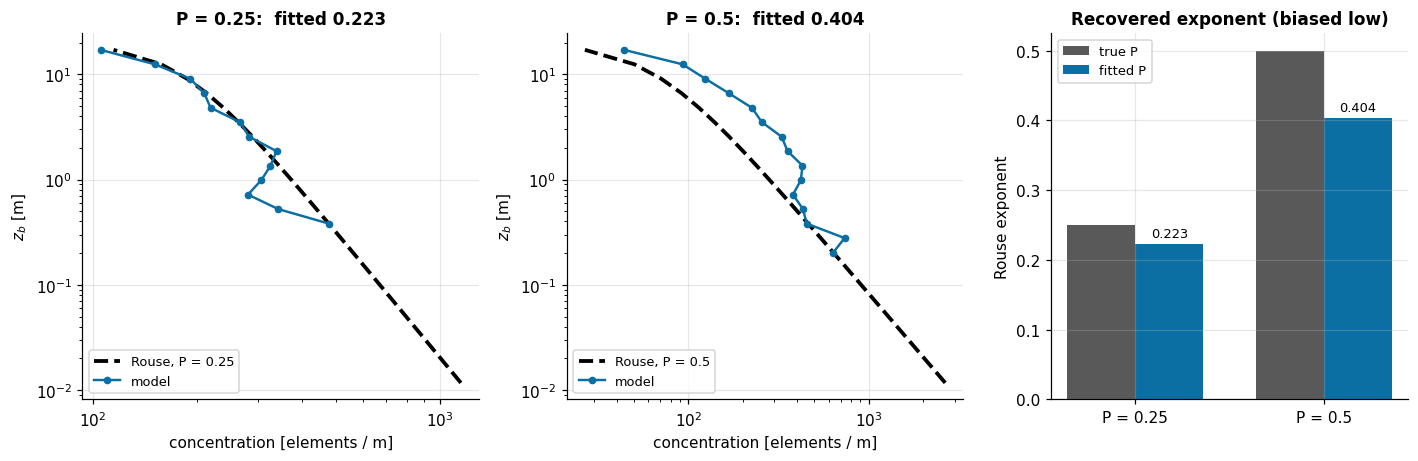

P = 0.25: fitted 0.223  (-11 %)
P = 0.5: fitted 0.404  (-19 %)


In [4]:
fig, axes = plt.subplots(1, len(PS) + 1, figsize=(13, 4.3),
                         gridspec_kw={'width_ratios': [1] * len(PS) + [0.9]})
fits = {}
for ax, P in zip(axes, PS):
    zbv = results[P]['zb']
    edges = np.logspace(np.log10(ZA), np.log10(H), 25)
    counts, _ = np.histogram(zbv, bins=edges)
    centres = np.sqrt(edges[1:] * edges[:-1])
    conc = counts / np.diff(edges)
    ok = counts > 20
    Pfit = np.polyfit(np.log((H - centres[ok]) / centres[ok]), np.log(conc[ok]), 1)[0]
    fits[P] = Pfit

    ref = rouse_profile(centres, P, H, ZA)
    scale = conc[ok][0] / ref[ok][0]
    ax.plot(ref * scale, centres, color='k', lw=2.5, ls='--', label=f'Rouse, P = {P}')
    ax.plot(conc[ok], centres[ok], 'o-', color=CLR[0], ms=4, lw=1.6, label='model')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('concentration [elements / m]'); ax.set_ylabel(r'$z_b$ [m]')
    ax.set_title(f'P = {P}:  fitted {Pfit:.3f}')
    ax.legend(fontsize=8.5, loc='lower left')

ax = axes[-1]
x = np.arange(len(PS))
ax.bar(x - .18, PS, .36, color='0.35', label='true P')
ax.bar(x + .18, [fits[P] for P in PS], .36, color=CLR[0], label='fitted P')
for i, P in enumerate(PS):
    ax.text(i + .18, fits[P] + .01, f'{fits[P]:.3f}', ha='center', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels([f'P = {P}' for P in PS])
ax.set_ylabel('Rouse exponent'); ax.set_title('Recovered exponent (biased low)')
ax.legend(fontsize=8.5)
plt.tight_layout(); plt.show()
for P in PS:
    print(f"P = {P}: fitted {fits[P]:.3f}  ({100*(fits[P]-P)/P:+.0f} %)")

## Verdict, and a documented bias

**PASS** — the fitted exponent lands within the 0.55–1.15 $\times P$ tolerance,
and the modelled profile tracks the Rouse shape over more than two decades of
concentration. The settling-versus-mixing balance is right.

**But the estimate is systematically low**, and the reason is worth recording.
Elements resting on the bed between lift-offs are not part of the suspended
profile, so near-bed concentration is under-counted and the profile flattens. A
sweep over how that population is treated:

| $P$ | outer $\Delta t$ | duration | bed-resting | fitted $P$ |
|---|---|---|---|---|
| 0.25 | 300 s | 24 h | 267 | **0.223** (excluded — what we do) |
| 0.25 | 300 s | 24 h | 267 | 0.582 (counted at $z_a$) |
| 0.25 | 60 s | 24 h | 54 | 0.407 (counted at $z_a$) |
| 0.25 | 60 s | 48 h | 47 | 0.443 (counted at $z_a$) |

Counting them at the release height over-corrects badly; excluding them is much
the better estimator. Shrinking the time step shrinks the bed-resting population
as expected (267 → 54 for a 5× smaller step), which confirms this is a
**discretisation artifact of the lift-off cycle**, not a physical result.

At $P \gtrsim 1$ so much material sits on the bed that the suspended population
becomes too small to fit, so this benchmark is scoped to $P \lesssim 0.5$.